# 04 - Steam churn sensitivity analysis: playtime (v1) vs library breadth (v2)

This notebook inspects the output of `src/sensitivity.py`, which trains a model
against each of two independent Steam churn definitions on the same
train/validation split and compares label agreement, model performance, feature
importance, and segment-level churn rates.

- **v1 (playtime percentile):** bottom 20% of `total_playtime_value`. Circular with
  its own top model features (documented in `steam_real/README.md` and
  `results/baseline_metrics.json`).
- **v2 (library breadth):** bottom 20% of `play_ratio = unique_games / owned_games`
  -- how much of a user's purchased game library they actually played. Built from
  "purchase" events in `steam-200k.csv` that the original pipeline discarded.
  Independent of playtime depth.

This notebook does not retrain anything -- it loads
`results/sensitivity_analysis.json`, generated by running
`python -m src.sensitivity` (or `run_sensitivity_analysis()`) from `steam_real/`.

In [1]:
import json
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
with open(PROJECT_ROOT / "results" / "sensitivity_analysis.json") as f:
    sens = json.load(f)

print(sens["note"])

v1 here is retrained on a shared, unstratified split for a fair comparison with v2. This is NOT the same model/split as the original churn_model.pkl documented in Issue 1's baseline_metrics.json (that one used a stratified split). Both v1 numbers are legitimate; they answer different questions.


## Label agreement between definitions

In [2]:
agreement = sens["label_agreement"]
pd.Series(agreement).drop(["confusion_matrix_v1_vs_v2"])

n_users                          11350
prevalence_v1                   0.2037
prevalence_v2                 0.224317
agreement_rate                 0.65304
disagreement_rate              0.34696
n_agree                           7412
n_disagree                        3938
n_label_changed                   3938
pct_label_changed                 34.7
newly_churned_under_v2            2086
no_longer_churned_under_v2        1852
cohens_kappa                 -0.030686
dtype: object

In [3]:
pd.DataFrame(agreement["confusion_matrix_v1_vs_v2"], index=[0]).T.rename(columns={0: "count"})

,count
v1_0_v2_0,6952
v1_0_v2_1,2086
v1_1_v2_0,1852
v1_1_v2_1,460


Cohen's kappa near zero (or negative) means the two definitions agree no better
than random chance -- they are identifying substantially different users as
"churned", not the same population measured two different ways.

## Model performance: v1 vs. v2 (same split, same model family, same eval functions)

In [4]:
perf_rows = []
for key, label in [("v1", "v1 (playtime)"), ("v2", "v2 (library breadth)")]:
    m = sens[key]["metrics"]
    d = sens[key]["dummy_baseline_metrics"]
    perf_rows.append({
        "definition": label,
        "n_val": sens[key]["n_val"],
        "prevalence_val": m["prevalence_val"],
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "dummy_roc_auc": d["roc_auc"],
        "dummy_pr_auc": d["pr_auc"],
    })
pd.DataFrame(perf_rows).set_index("definition")

,n_val,prevalence_val,accuracy,precision,recall,f1,roc_auc,pr_auc,dummy_roc_auc,dummy_pr_auc
definition,,,,,,,,,,
v1 (playtime),2270,0.193392,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.509900,0.196711
v2 (library breadth),2270,0.216740,0.728194,0.217195,0.097561,0.134642,0.488814,0.22147,0.505464,0.218664


v1's near-1.0 metrics reflect label circularity (`total_playtime_value` is both the
label source and a top feature), not genuine predictive skill. v2's ROC-AUC sits
close to its own DummyClassifier baseline -- the playtime-depth feature set used
here carries little to no signal about library-breadth churn, consistent with the
near-zero label agreement above.

## Feature importance: v1 vs. v2 (permutation importance, same method, shared features only)

In [5]:
ranking = sens["common_feature_importance_ranking"]
pd.DataFrame({"v1_rank": ranking["v1_rank"], "v2_rank": ranking["v2_rank"]}, index=range(1, len(ranking["v1_rank"]) + 1))

,v1_rank,v2_rank
1,total_playtime_value,sessions
2,playtime_per_game,total_playtime_value
3,sessions,playtime_per_game
4,avg_session_length,avg_session_length


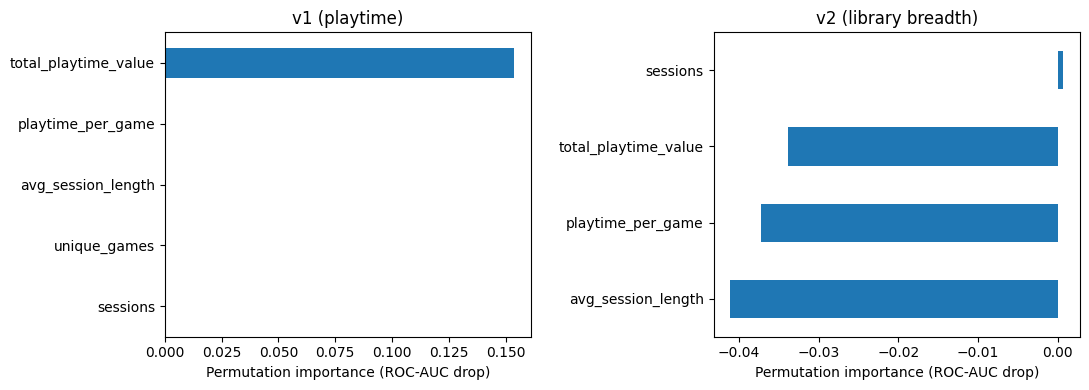

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, key, title in zip(axes, ["v1", "v2"], ["v1 (playtime)", "v2 (library breadth)"]):
    imp = sens[key]["permutation_importance"]["mean"]
    s = pd.Series(imp).sort_values()
    s.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Permutation importance (ROC-AUC drop)")
plt.tight_layout()
plt.show()

## Churn rate by playtime tier: v1 vs. v2

In [7]:
seg = pd.DataFrame(sens["segment_comparison"]["segments"]).set_index("playtime_tier")
seg = seg.reindex(["Very Low", "Low", "Medium", "High", "Very High"])
seg[["segment_size", "churn_rate_v1", "churn_rate_v2"]]

,segment_size,churn_rate_v1,churn_rate_v2
playtime_tier,,,
Very Low,2312,1.0,0.198962
Low,2251,0.0,0.200800
Medium,2248,0.0,0.227313
High,2269,0.0,0.245483
Very High,2270,0.0,0.249339


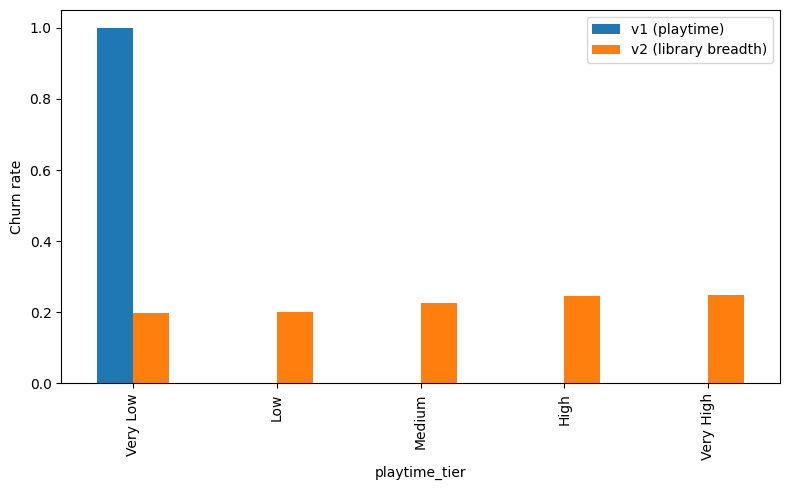

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
seg[["churn_rate_v1", "churn_rate_v2"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Churn rate")
ax.legend(["v1 (playtime)", "v2 (library breadth)"])
plt.tight_layout()
plt.show()

v1's churn rate is trivially 100% in the lowest playtime tier and 0% everywhere
else, by construction. v2's churn rate is roughly flat across every tier
(~20-25%): library-breadth disengagement is not concentrated among low-playtime
users. This is further evidence the two definitions capture different constructs,
not the same underlying "at risk" population.

## High-risk user overlap

In [9]:
hr = sens["segment_comparison"]
pd.Series({
    "high_risk_v1_count": hr["high_risk_v1_count"],
    "high_risk_v2_count": hr["high_risk_v2_count"],
    "overlap_count": hr["high_risk_overlap_count"],
    "overlap_pct_of_v1": hr["high_risk_overlap_pct_of_v1"],
    "overlap_pct_of_v2": hr["high_risk_overlap_pct_of_v2"],
})

high_risk_v1_count    2312.00
high_risk_v2_count    2546.00
overlap_count          460.00
overlap_pct_of_v1       19.90
overlap_pct_of_v2       18.07
dtype: float64

Only ~18-20% of users flagged "high risk" under one definition are also flagged
under the other. A retention team acting on v1 alone would target a largely
different set of users than one acting on v2 alone -- this is the core, concrete
consequence of churn-definition choice that this sensitivity analysis was built
to surface.